# Fase 5: Inteligencia Artificial Explicable (XAI) y validación clínica
### Hacia un Sistema de Soporte a la Decisión Clínica (CDSS) Transparente

### 1. Objetivo Principal
Este cuaderno documenta la fase final del TFM. El objetivo es ir más allá de la predicción pura: queremos entender por qué el modelo clasifica a cada paciente como lo hace, y que esa explicación sea comprensible para un médico, no solo para un científico de datos.

### 2. Justificación metodológica
En medicina, los algoritmos de caja negra generan desconfianza, y con razón. Para abordar esto, confrontamos la lógica interna de XGBoost (explicada mediante valores SHAP) con la interpretabilidad nativa del EBM. Si ambos modelos coinciden en qué variables importan y cómo, la explicación es robusta y no depende del algoritmo elegido.

### 3. Estructura del análisis (De lo Global a lo Local)
1. **Consenso multimodelo (Global XAI):** ¿Los dos modelos se fijan en las mismas variables?
2. **Firma biométrica y umbrales:** ¿A partir de qué valor una variable se vuelve peligrosa? (PDP)
3. **Descubrimiento de fenotipos (Clustering):** ¿Hay distintos "tipos" de Alzheimer en los datos?
4. **Auditoría clínica:** Análisis de los errores del modelo (Falsos Positivos/Negativos).
5. **Reporte médico detallado (Local XAI):** Explicación caso a caso con LIME y Anchors.
6. **Simulación contrafactual:** ¿Cuánto tiene que empeorar un paciente sano para cruzar el umbral?

In [2]:
import joblib
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from interpret import show
from anchor import anchor_tabular
from sklearn.cluster import KMeans
from sklearn.inspection import partial_dependence
import math
import shap

%matplotlib inline
from matplotlib.ticker import AutoMinorLocator



# recperamos el diccionario con todo mi trabajo de la fase anterior
m = joblib.load('../models/modelo_final_tfm_darwin11.pkl')

# Extraigo los datos y los modelos para tenerlos a mano
X_train_xai = m['X_train_final']
X_test_final = m['X_test_final']
y_test = m['y_test']
columnas = m['columnas']
xgb_final = m['modelo_xgb']
ebm_final = m['modelo_ebm']

# dejamos la configuración visual lista para las gráficas de esta sección
sns.set_theme(style="whitegrid")
shap.initjs()

### 1. Consenso Multimodelo (Explicabilidad Global)

Partiendo del protocolo reducido a 11 tareas, el primer paso normativo es verificar si nuestros dos algoritmos estrella (XGBoost y EBM) toman decisiones basándose en la misma información médica. 

Para ello, calculamos la importancia de las variables en la "Caja Negra" usando la teoría de juegos (valores SHAP) y la extraemos directamente de las funciones de forma de la "Caja Blanca" (EBM), generando un mapa de consenso biológico.

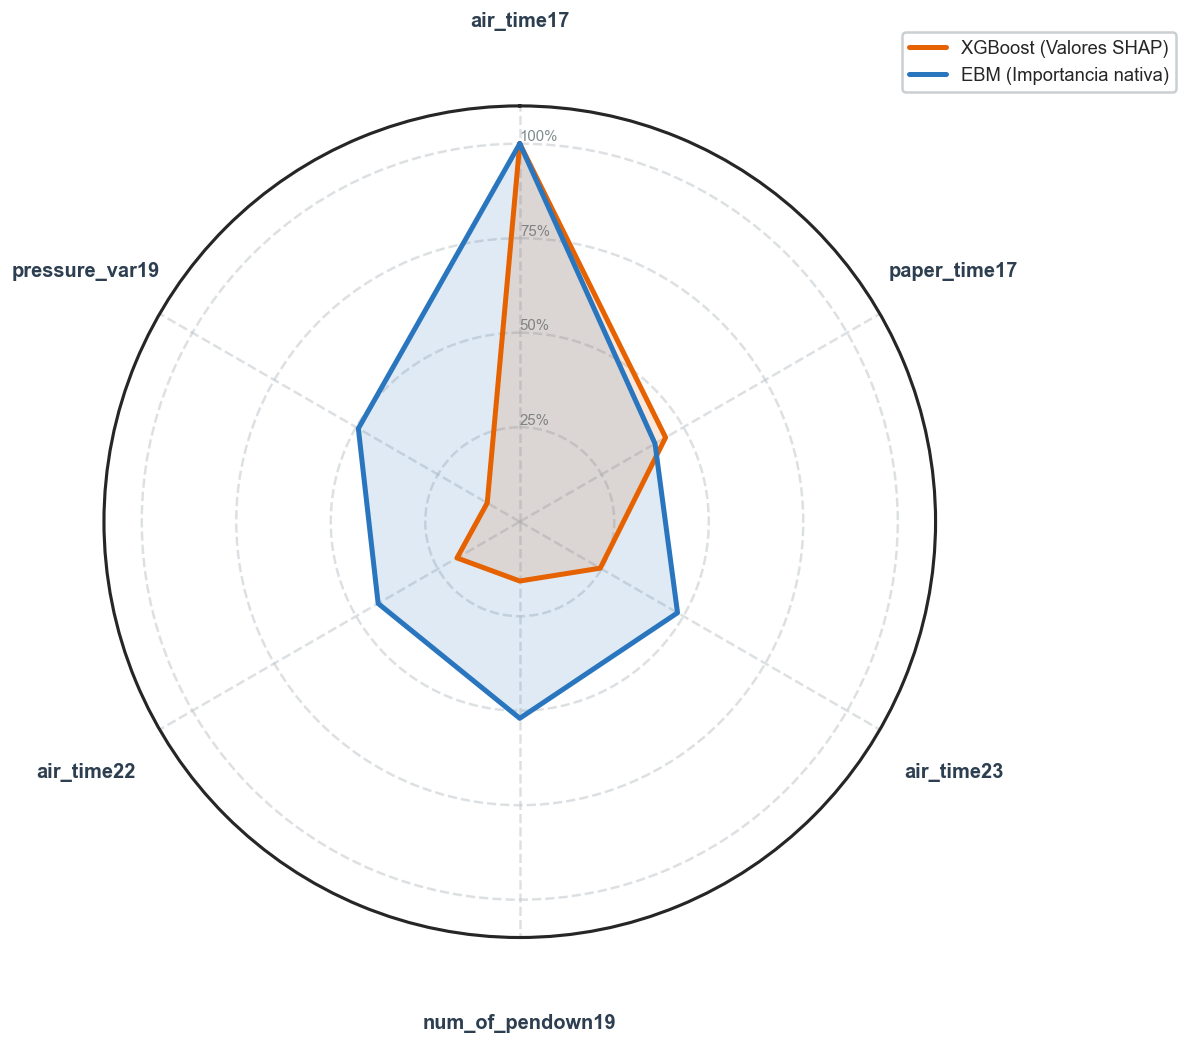

Top 10 biomarcadores: consenso clínico y dominio asociado
-----------------------------------------------------------------
                  MEDIA_CONSENSO                    Dominio
air_time17            100.000000  COGNITIVO (Planificación)
paper_time17           42.930391                      OTROS
air_time23             36.386370  COGNITIVO (Planificación)
num_of_pendown19       33.853583                      OTROS
air_time22             31.218271  COGNITIVO (Planificación)
pressure_var19         29.623033             MOTOR (Fuerza)
gmrt_on_paper8         25.456268  COGNITIVO (Planificación)
pressure_mean8         23.251278             MOTOR (Fuerza)
gmrt_in_air8           20.997208  COGNITIVO (Planificación)
disp_index22           20.307392                      OTROS
-----------------------------------------------------------------


In [3]:
explainer_xgb = shap.TreeExplainer(xgb_final)
shap_values_xgb = explainer_xgb(X_test_final)
imp_xgb = np.abs(shap_values_xgb.values).mean(0)

ebm_global = ebm_final.explain_global()
dict_ebm = dict(zip(ebm_global.data()['names'], ebm_global.data()['scores']))
imp_ebm = [dict_ebm.get(col, 0) for col in columnas]

df_consenso = pd.DataFrame({'XGBoost_SHAP': imp_xgb, 'EBM_Native': imp_ebm}, index=columnas)
df_consenso = (df_consenso / df_consenso.max()) * 100 
df_consenso['MEDIA_CONSENSO'] = df_consenso.mean(axis=1)

# Clasificación por dominio clínico
def clasificar_dominio(var):
    v = var.lower()
    if 'air_time' in v or 'gmrt' in v: return 'COGNITIVO (Planificación)'
    if 'pressure' in v: return 'MOTOR (Fuerza)'
    if 'speed' in v or 'jerk' in v or 'velocity' in v: return 'MOTOR (Coordinación)'
    return 'OTROS'

df_consenso['Dominio'] = [clasificar_dominio(v) for v in df_consenso.index]
df_resumen = df_consenso.sort_values(by='MEDIA_CONSENSO', ascending=False)

# Preparamos el Radar con el Top 6
top_n = 6
df_radar = df_resumen.head(top_n).copy()
labels = df_radar.index.tolist()
N = len(labels)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

sns.set_theme(style="white", context="talk")
fig = plt.figure(figsize=(9, 9), dpi=120)
fig.patch.set_facecolor('#FFFFFF')
ax = plt.subplot(111, polar=True)
ax.set_facecolor('#FFFFFF')

color_ebm = '#2A76BE' 
color_xgb = '#E66100'
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], labels, color='#2C3E50', size=12, fontweight='bold')
ax.tick_params(axis='x', pad=35) 
ax.set_rlabel_position(0)
plt.yticks([25, 50, 75, 100], ["25%", "50%", "75%", "100%"], color="#7F8C8D", size=9)
plt.ylim(0, 110)
ax.grid(color='#BDC3C7', linestyle='--', alpha=0.5)
values_xgb = df_radar['XGBoost_SHAP'].tolist() + [df_radar['XGBoost_SHAP'].iloc[0]]
ax.plot(angles, values_xgb, linewidth=3, color=color_xgb, label='XGBoost (Valores SHAP)', zorder=4)
ax.fill(angles, values_xgb, color=color_xgb, alpha=0.15)
values_ebm = df_radar['EBM_Native'].tolist() + [df_radar['EBM_Native'].iloc[0]]
ax.plot(angles, values_ebm, linewidth=3, color=color_ebm, label='EBM (Importancia nativa)', zorder=5)
ax.fill(angles, values_ebm, color=color_ebm, alpha=0.15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=True, 
           facecolor='white', edgecolor='#BDC3C7', fontsize=11)
plt.show()

# Resumen en tabla
print("Top 10 biomarcadores: consenso clínico y dominio asociado")
print("-"*65)
print(df_resumen[['MEDIA_CONSENSO', 'Dominio']].head(10).to_string())
print("-"*65)

El solapamiento en el radar es una buena señal: ambos modelos priorizan las mismas variables, lo que indica que no están capturando ruido sino patrones reales. De la tabla de consenso extraemos tres conclusiones:

1. **Prevalencia del dominio cognitivo:** `air_time17` domina con un 100% de importancia normalizada. Que los tiempos en el aire estén tan representados en el Top 10 confirma que la EA se manifiesta principalmente como lentitud en la planificación, no en la ejecución motora.
2. **Relevancia de la Tarea 17:** Esta tarea específica parece concentrar la mayor carga cognitiva del protocolo, lo que la convierte en la más informativa para el diagnóstico.
3. **Apoyo motor:** Las variables de presión (`pressure_var19`, `pressure_var17`) aparecen como segundo factor, lo que tiene sentido clínicamente: la pérdida de control sobre la fuerza acompaña al deterioro cognitivo.

A continuación miramos *cómo* afecta cada variable a la predicción y si hay un umbral claro de riesgo.

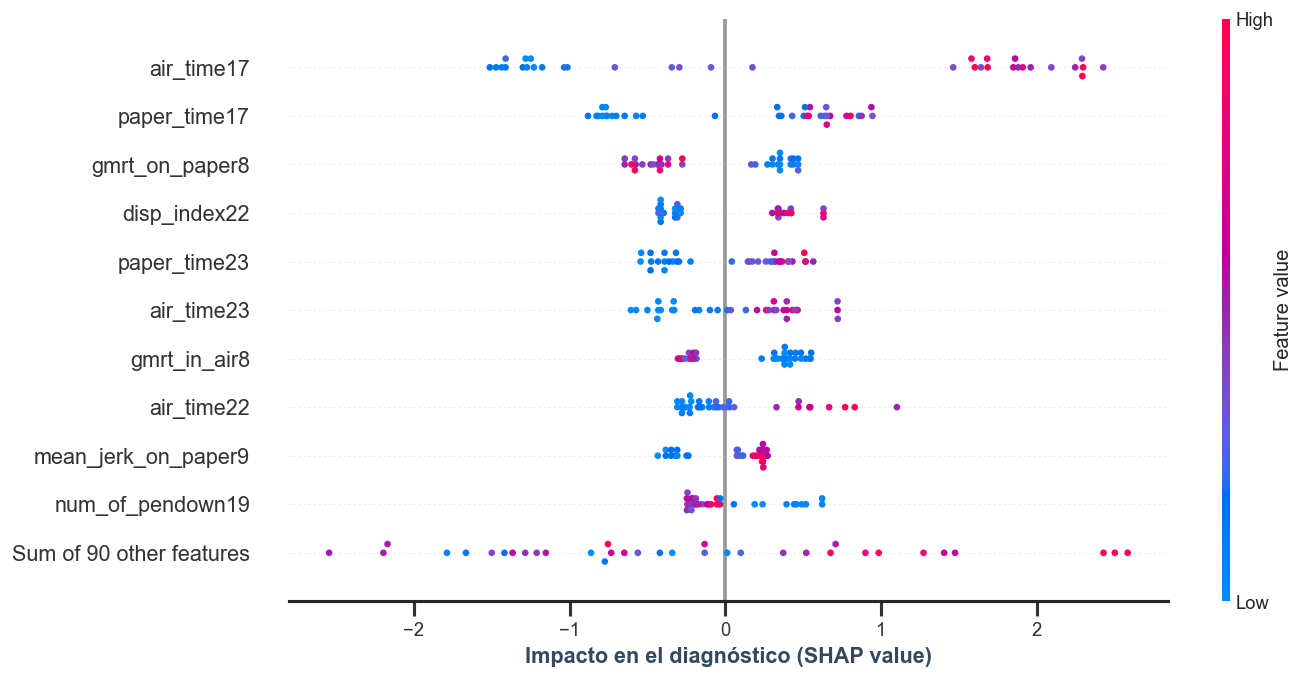

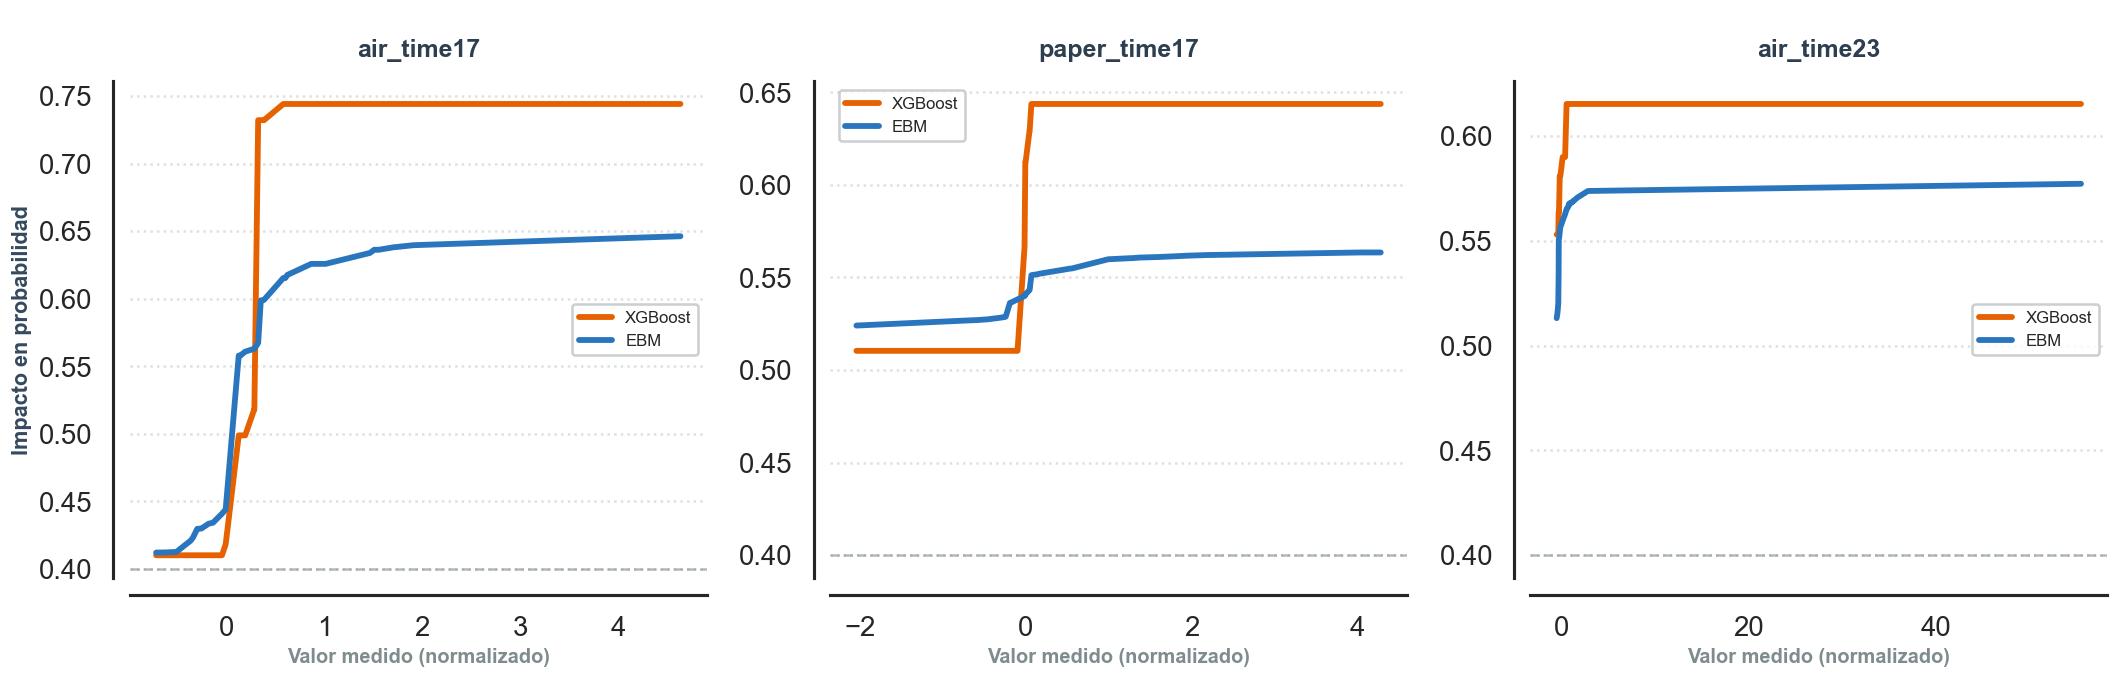

In [4]:
# SHAP (XGBOOST)
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(12, 6), dpi=120)
plt.gcf().patch.set_facecolor('#FFFFFF')

shap.plots.beeswarm(shap_values_xgb, max_display=11, show=False, plot_size=None)
plt.xlabel("Impacto en el diagnóstico (SHAP value)", fontsize=13, fontweight='bold', color='#34495E')
plt.gcf().axes[-1].set_facecolor('#FAFCFF')
plt.tight_layout()
plt.show()

# Validación de umbrales PDP puntos de ruptura 
top_3_vars = df_resumen.index[:3].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=120)
fig.patch.set_facecolor('#FFFFFF')
color_ebm = '#2A76BE'
color_xgb = '#E66100'

for i, var in enumerate(top_3_vars):
    ax = axes[i]
    ax.set_facecolor('#FFFFFF')
    pdp_xgb = partial_dependence(xgb_final, X_test_final, [var], grid_resolution=50)
    pdp_ebm = partial_dependence(ebm_final, X_test_final, [var], grid_resolution=50)
    x_axis = pdp_xgb['grid_values'][0]
    ax.plot(x_axis, pdp_xgb['average'][0], color=color_xgb, label='XGBoost', 
            linewidth=3.5, zorder=4)
    ax.plot(x_axis, pdp_ebm['average'][0], color=color_ebm, label='EBM', 
            linewidth=3.5, zorder=5)

    ax.set_title(f"\n{var}", fontsize=15, fontweight='bold', color='#2C3E50', pad=15)
    ax.set_xlabel("Valor medido (normalizado)", fontsize=12, fontweight='bold', color='#7F8C8D')
    
    if i == 0: 
        ax.set_ylabel("Impacto en probabilidad", fontsize=13, fontweight='bold', color='#34495E')
    else:
        ax.set_ylabel("")

    ax.axhline(0.4, color='#7F8C8D', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
    
    ax.grid(axis='y', linestyle=':', alpha=0.5, color='#BDC3C7')
    
    ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='#BDC3C7', fontsize=10)

sns.despine(offset=10)
plt.tight_layout()
plt.show()

### Descubrimiento de Fenotipos Clínicos (Clustering SHAP)

El Alzheimer no se manifiesta igual en todos los pacientes. Para ir más allá del diagnóstico binario ("Sano" vs "Enfermo"), vamos a aislar exclusivamente a los pacientes enfermos y a aplicar un algoritmo de aprendizaje no supervisado (**K-Means**) sobre sus explicaciones locales (valores SHAP).

Con ello, queremos descubrir si se detectan diferentes "caminos" o perfiles de síntomas que conducen a la misma predicción de riesgo, abriendo la puerta a terapias personalizadas.

k=2 → Silhouette Score: 0.403
k=3 → Silhouette Score: 0.206
k=4 → Silhouette Score: 0.223
k=5 → Silhouette Score: 0.161

k óptimo según Silhouette: 2


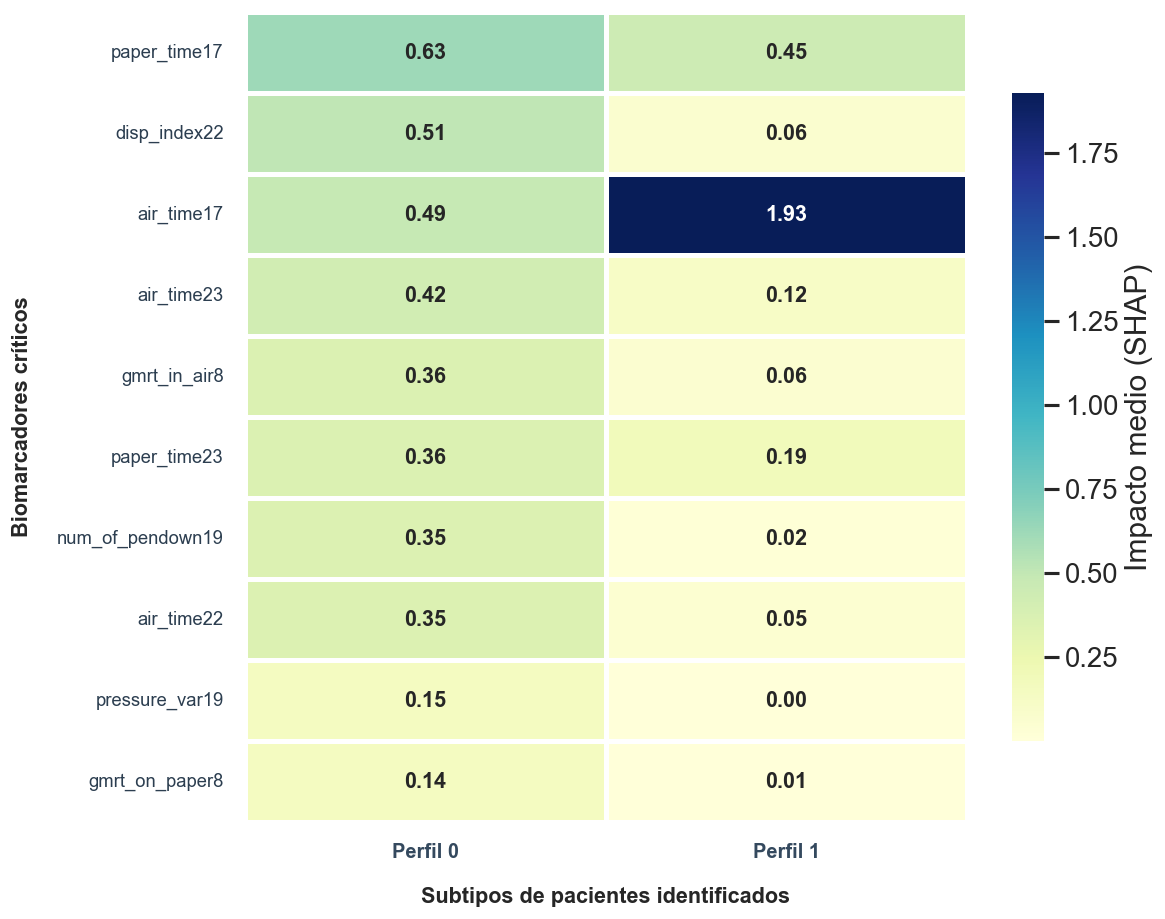

In [5]:
preds = xgb_final.predict(X_test_final)
indices_alz = np.where(preds == 1)[0]
shap_alz = shap_values_xgb.values[indices_alz]
# Justificación del número de clusters mediante Silhouette Score
from sklearn.metrics import silhouette_score

rango_k = range(2, 6)
silhouettes = []

for k in rango_k:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(shap_alz)
    sil = silhouette_score(shap_alz, labels_temp)
    silhouettes.append(sil)
    print(f"k={k} → Silhouette Score: {sil:.3f}")

k_optimo = list(rango_k)[np.argmax(silhouettes)]
print(f"\nk óptimo según Silhouette: {k_optimo}")
# Aplicamos K-Means para encontrar patrones en las razones del diagnóstico
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(shap_alz)

# Creamos el resumen de impacto medio por subtipo
df_pheno = pd.DataFrame(shap_alz, columns=columnas)
df_pheno['Subtipo'] = [f'Perfil {c}' for c in clusters]
resumen_pheno = df_pheno.groupby('Subtipo').mean().T

resumen_plot = resumen_pheno.abs().sort_values(by='Perfil 0', ascending=False).head(10)

sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 8), dpi=120)
plt.gcf().patch.set_facecolor('#FFFFFF')

ax = sns.heatmap(resumen_plot, 
                 annot=True, 
                 cmap='YlGnBu',
                 fmt=".2f", 
                 linewidths=3,
                 linecolor='white',
                 cbar_kws={"label": "Impacto medio (SHAP)", "shrink": .8},
                 annot_kws={"size": 13, "weight": "bold"},
                 ax=plt.gca())

plt.xlabel("Subtipos de pacientes identificados", fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel("Biomarcadores críticos", fontsize=13, fontweight='bold', labelpad=15)

# Estilizamos las etiquetas de los ejes
plt.xticks(fontsize=12, fontweight='bold', color='#34495E')
plt.yticks(fontsize=11, color='#2C3E50')

plt.tight_layout()
plt.show()

**Conclusión — Fenotipos encontrados:**
* **Perfil 1 (Bloqueo Cognitivo Focalizado):** Casi toda la señal viene de `air_time17`. Son pacientes que en términos motores aún funcionan relativamente bien, pero que se bloquean específicamente en la fase de planificación del trazo.
* **Perfil 0 (Deterioro Distribuido):** El impacto se reparte entre más variables: velocidad, presión y pausas. Un deterioro más generalizado.

Esto es útil en la práctica: no es lo mismo derivar a un paciente a estimulación cognitiva que a rehabilitación motora. El clustering sobre valores SHAP permite hacer esa distinción.

### 4. Auditoría Clínica: Transparencia en aciertos y errores

Un modelo médico ético debe ser totalmente transparente con sus fallos. Extraemos un paciente real de cada cuadrante de la matriz de confusión (Verdaderos y Falsos Positivos/Negativos) para analizar sus gráficos *Waterfall* de SHAP. 

Observando los errores (Falsos), entenderemos si el modelo falla por "alucinación matemática" o si, por el contrario, comete errores clínicamente comprensibles (ej., un enfermo en fase muy incipiente que aún conserva una caligrafía ágil).

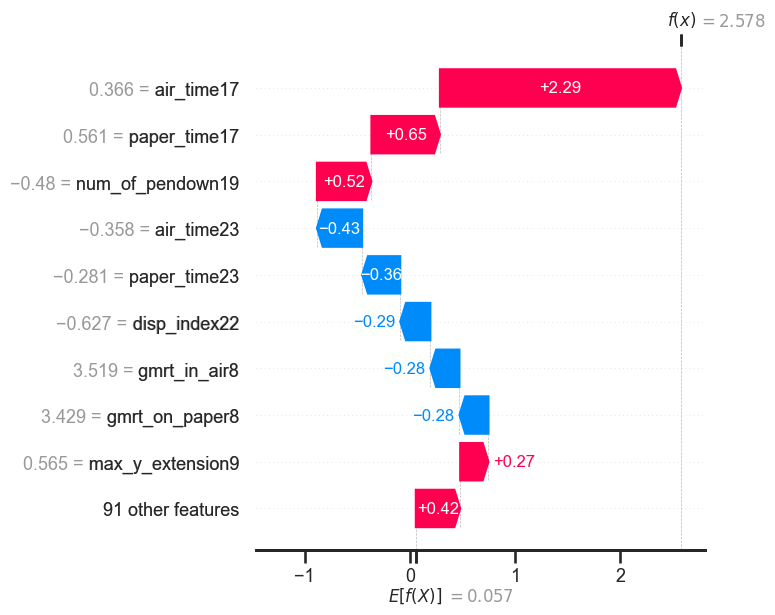

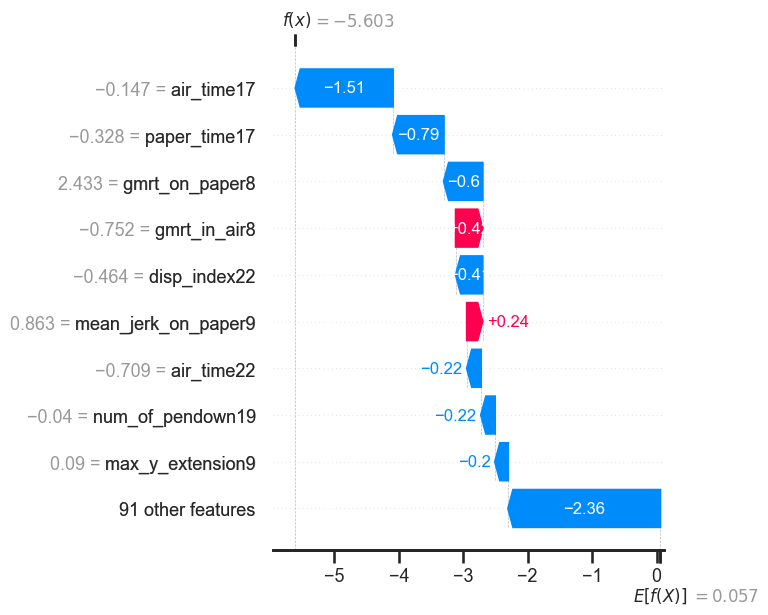

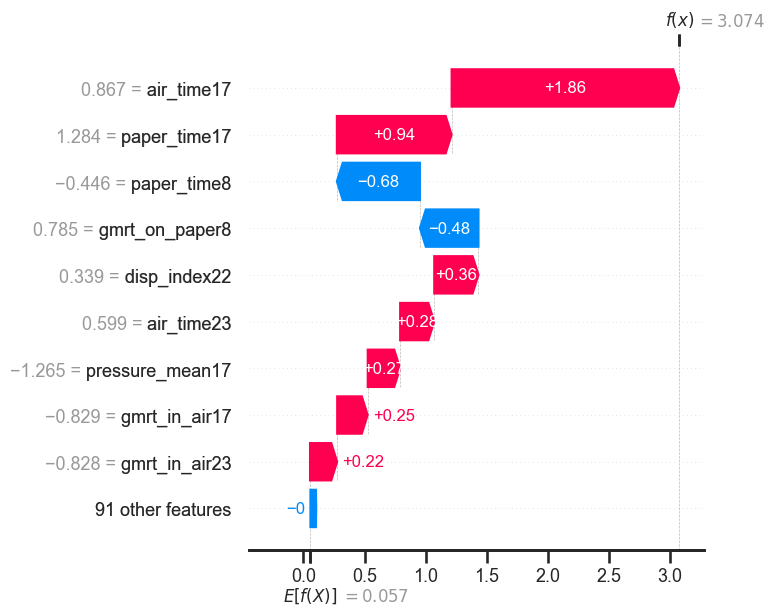

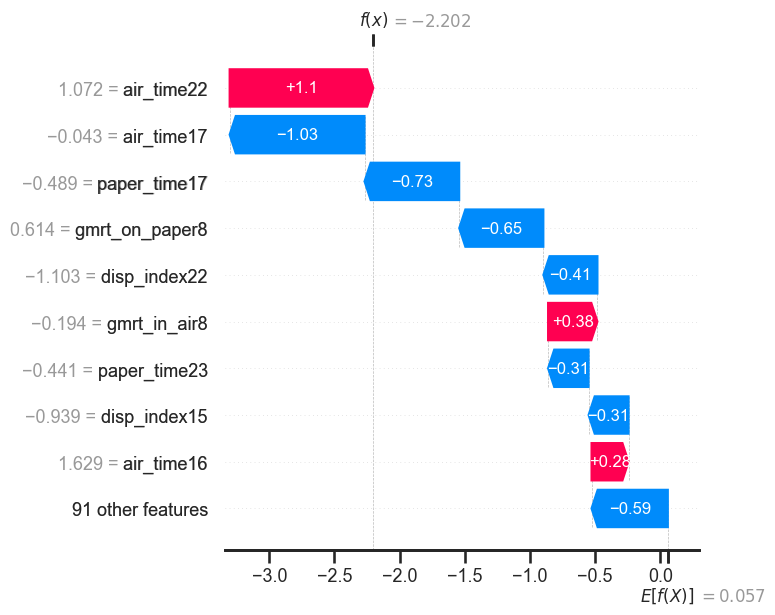

In [6]:
y_real = y_test.values

# Busco el primer índice de paciente que encaje en cada supuesto
try: tp_idx = np.where((preds == 1) & (y_real == 1))[0][0]
except: tp_idx = None
try: tn_idx = np.where((preds == 0) & (y_real == 0))[0][0]
except: tn_idx = None
try: fp_idx = np.where((preds == 1) & (y_real == 0))[0][0]
except: fp_idx = None
try: fn_idx = np.where((preds == 0) & (y_real == 1))[0][0]
except: fn_idx = None

casos = [
    ("VERDADERO POSITIVO", tp_idx, "Detección correcta"),
    ("VERDADERO NEGATIVO", tn_idx, "Sano correcto"),
    ("FALSO POSITIVO", fp_idx, "Sano clasificado como Alzheimer"),
    ("FALSO NEGATIVO", fn_idx, "Alzheimer no detectado")
]

for titulo, idx_caso, subtitulo in casos:
    if idx_caso is not None:
        plt.figure(figsize=(8, 3))
        shap.plots.waterfall(shap_values_xgb[idx_caso], max_display=10, show=False)
        plt.tight_layout()
        plt.show()

### 5. Reporte médico detallado (Local XAI)

Para que el sistema sea útil en consulta, demostramos cómo se le presentaría el diagnóstico de un paciente específico (Paciente #2) a un facultativo. 

Utilizaremos explicabilidad agnóstica (**LIME**) para validar los pesos locales, y extraeremos una **Regla Ancla (Anchors)**: una combinación de condiciones lógicas absolutas legibles (estilo *"Si A y B, entonces Alzheimer"*) que el médico puede leer e interpretar fácilmente.

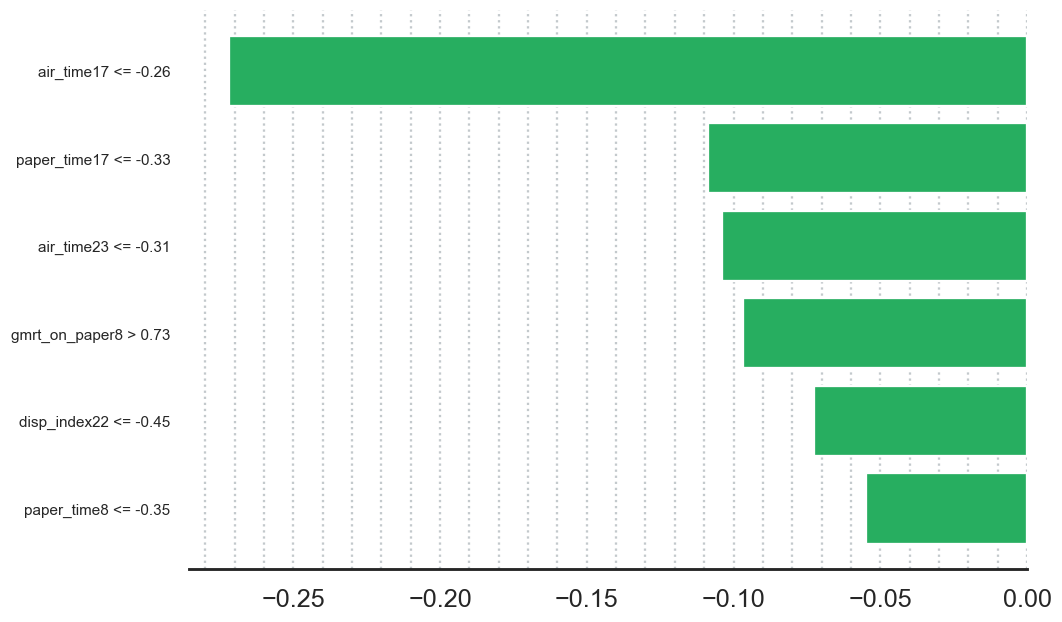

Protocolo de decisión Anchor del paciente nº2
Diagnóstico:Sano
La regla lógica:air_time17 <= -0.26 AND air_time23 <= -0.31
Precisión: 91.7% de confianza en esta regla.
Si se cumplen estas condiciones, el modelo clasifica al
sujeto como Sano con una estabilidad del 92%.


<!-- http://127.0.0.1:7001/5624595152/ -->

In [7]:
idx = 2
paciente_datos = X_test_final.iloc[[idx]]

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_xai.values, feature_names=columnas, 
    class_names=['Sano', 'Alzheimer'], mode='classification'
)
exp = explainer_lime.explain_instance(paciente_datos.values[0], xgb_final.predict_proba, num_features=6)

nombres, pesos = zip(*exp.as_list())
colores = ['#C0392B' if w > 0 else '#27AE60' for w in pesos]

plt.figure(figsize=(10, 6), dpi=110)
plt.gcf().patch.set_facecolor('#FFFFFF')
ax = plt.gca()
ax.set_facecolor('#FFFFFF')
ax.barh(nombres, pesos, color=colores, edgecolor='white', linewidth=1.5, zorder=3)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(which='both', axis='x', linestyle=':', color='#BDC3C7', alpha=0.9, zorder=0)

ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=10)
sns.despine(left=True)
plt.tight_layout()
plt.show()


def predict_wrapper(x):
    return xgb_final.predict(pd.DataFrame(x, columns=columnas))

explainer_anchor = anchor_tabular.AnchorTabularExplainer(
    class_names=['Sano', 'Alzheimer'], feature_names=columnas,
    train_data=X_train_xai.values, categorical_names={}
)

explanation = explainer_anchor.explain_instance(X_test_final.iloc[idx].values, predict_wrapper, threshold=0.90)
clase_predicha = xgb_final.predict(paciente_datos)[0]
etiqueta_pred = "Alzheimer" if clase_predicha == 1 else "Sano"

print(f"Protocolo de decisión Anchor del paciente nº{idx}")
print(f"Diagnóstico:{etiqueta_pred}")
print(f"La regla lógica:{' AND '.join(explanation.names())}")
print(f"Precisión: {explanation.precision()*100:.1f}% de confianza en esta regla.")
print(f"Si se cumplen estas condiciones, el modelo clasifica al")
print(f"sujeto como {etiqueta_pred} con una estabilidad del {explanation.precision()*100:.0f}%.")


ebm_local = ebm_final.explain_local(paciente_datos, y_test.iloc[[idx]])
show(ebm_local)


In [8]:

ebm_global = ebm_final.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/5704985936/ -->

### 6. Hacia un Modelo Prescriptivo

La Inteligencia Artificial médica no debe limitarse a emitir un veredicto porque debe proporcionar vías de acción. Para terminar, convertimos nuestro modelo predictivo en una herramienta de simulación dinámica (**What-If Analysis**). 

Vamos a seleccionar a un paciente "sano al límite" y simularemos computacionalmente cómo un empeoramiento progresivo y coordinado en la tarea clave acabaría disparando el diagnóstico, revelando la resiliencia neurológica real del sujeto.

In [12]:
mask_ea = y_test.values == 1
mask_ctrl = y_test.values == 0
vals = X_test_final['air_time17'].values

print("Media EA:", vals[mask_ea].mean())
print("Media Ctrl:", vals[mask_ctrl].mean())
print("Diferencia:", vals[mask_ea].mean() - vals[mask_ctrl].mean())


Media EA: 0.7002356214159995
Media Ctrl: 0.26891400402777366
Diferencia: 0.43132161738822583


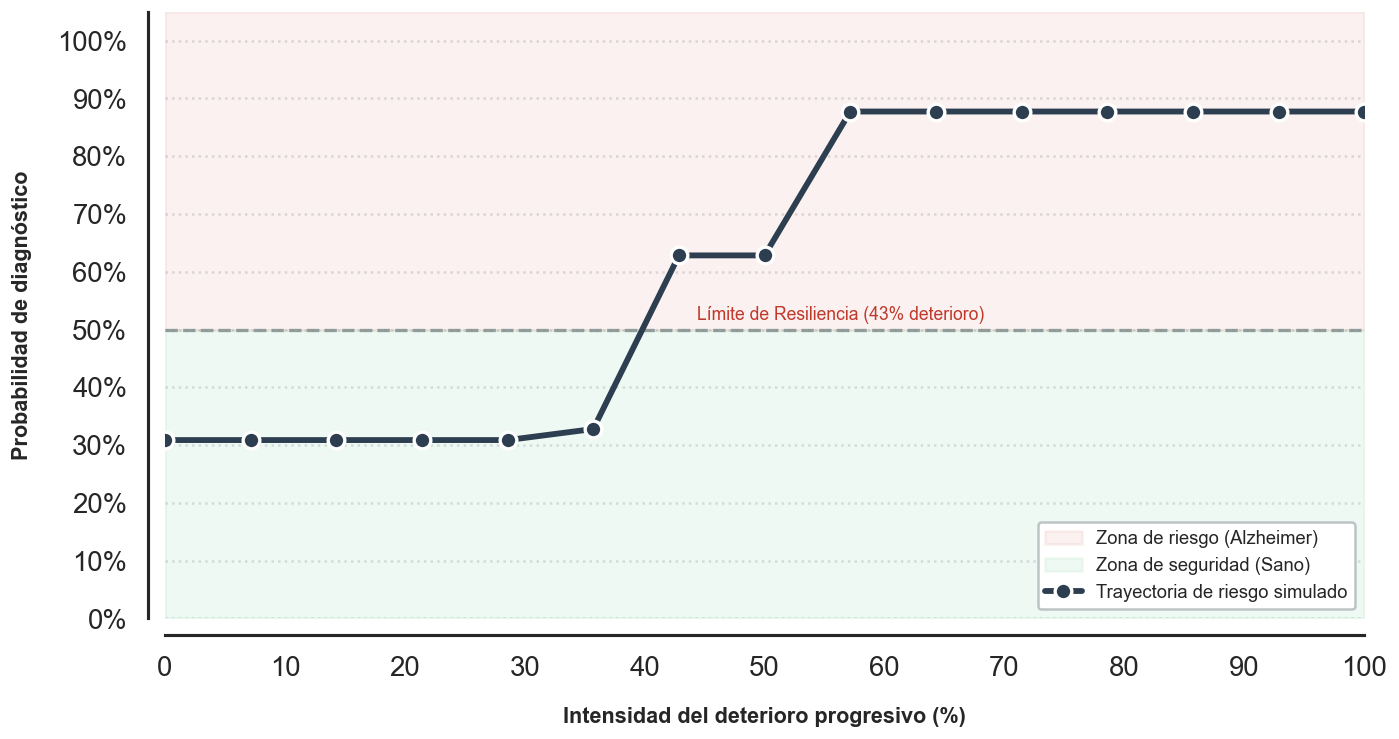

In [9]:
# Filtramos los verdaderos negativos (Sanos detectados como sanos)
tn_indices = np.where((preds == 0) & (y_real == 0))[0]
tn_probs = xgb_final.predict_proba(X_test_final.iloc[tn_indices])[:, 1]

# Localizamos al paciente "en el borde"
idx_borde = np.argmax(tn_probs)
idx_sim = tn_indices[idx_borde]
paciente_sim = X_test_final.iloc[[idx_sim]].copy()
prob_original = tn_probs[idx_borde]

# Seleccionamos el Top 1 de variables críticas según el consenso XAI

eje_x_pct = np.linspace(0, 100, 15) 
probs = []

var_principal = df_resumen.index[0]  # air_time17
valores_originales = {var_principal: paciente_sim[var_principal].values[0]}

for pct in eje_x_pct:
    unidades_a_sumar = (pct / 100.0) * 2.0
    paciente_sim[var_principal] = valores_originales[var_principal] + unidades_a_sumar
    prob_actual = xgb_final.predict_proba(paciente_sim)[0][1]
    probs.append(prob_actual)


sns.set_theme(style="white", context="talk")
plt.figure(figsize=(12, 6.5), dpi=120)
plt.gcf().patch.set_facecolor('#FFFFFF') 
ax = plt.gca()
ax.set_facecolor('#FFFFFF')

color_safe = '#27AE60'    
color_danger = '#C0392B'  
color_line = '#2C3E50'    
plt.fill_between(eje_x_pct, 0.5, 1.05, color=color_danger, alpha=0.07, label='Zona de riesgo (Alzheimer)')
plt.fill_between(eje_x_pct, 0, 0.5, color=color_safe, alpha=0.07, label='Zona de seguridad (Sano)')
plt.plot(eje_x_pct, probs, marker='o', color=color_line, linewidth=3.5, 
         markersize=10, markeredgecolor='white', markeredgewidth=2, 
         label='Trayectoria de riesgo simulado', zorder=5)
plt.axhline(0.5, color='#7F8C8D', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
plt.xlabel("Intensidad del deterioro progresivo (%)", fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel("Probabilidad de diagnóstico", fontsize=13, fontweight='bold', labelpad=15)
plt.xlim(0, 100)
plt.ylim(0, 1.05)
plt.xticks(np.arange(0, 101, 10), fontsize=11)
plt.yticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)], fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.5, color='#BDC3C7')

sns.despine(trim=False, offset=10)
probs_array = np.array(probs)
if any(probs_array >= 0.5):
    idx_cross = np.where(probs_array >= 0.5)[0][0]
    pct_cross = eje_x_pct[idx_cross]
    plt.text(pct_cross + 1.5, 0.51, f'Límite de Resiliencia ({pct_cross:.0f}% deterioro)', 
             color=color_danger, fontweight='normal', fontsize=10.5,
             verticalalignment='bottom', horizontalalignment='left')
plt.legend(loc='lower right', 
           frameon=True,
           facecolor='white',
           edgecolor='#BDC3C7',
           fontsize=11, 
           framealpha=1)

plt.tight_layout()
plt.show()

La simulación sobre el paciente sano más cercano al límite (riesgo basal: 30.9%) muestra un comportamiento no lineal, con tres fases bastante claras:

1. **Fase de Resiliencia (0% - 20%):** La probabilidad se mantiene estable por debajo del 50%. El modelo no se dispara ante pequeñas fluctuaciones, lo cual es importante: un enlentecimiento leve por edad no debería generar una alarma.
2. **Umbral de Ruptura (~43%):** Aquí la probabilidad salta bruscamente del 33% al 63% en muy poco margen de deterioro. Es el punto en que el modelo "decide" que la combinación de valores ya no encaja con un perfil sano.
3. **Saturación (>50%):** La probabilidad se estabiliza en torno al 88% y ya no sube más.

Lo más interesante es que el límite de resiliencia está en 0.86 unidades normalizadas, el doble de la separación entre grupos (0.43). Es decir, este paciente necesita deteriorarse bastante más allá del nivel medio del grupo EA para que el modelo lo clasifique como tal, lo que refleja que el modelo es conservador y específico.